In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model

from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings('ignore')

In [3]:
titanic = sns.load_dataset('titanic').dropna(subset = ['age'])
X = titanic[['age', 'fare']].values
y = titanic['survived'].values
print(X.shape)

(714, 2)


### A Basic Network
- One hidden layer with one node
- One output node
- Use the sigmoid activation function on all nodes

In [4]:
tf.random.set_seed(42)
single_node_model = Sequential([
    Dense(1, activation = 'sigmoid'),
    Dense(1, activation = 'sigmoid')
    ])

single_node_model

<Sequential name=sequential, built=False>

In [5]:
single_node_model.layers[0].activation

<function keras.src.activations.activations.sigmoid(x)>

In [6]:
# Compiling the Network
tf.random.set_seed(42)
single_node_model.compile(optimizer='rmsprop',
                         loss = 'binary_crossentropy',
                         metrics = ['accuracy'])

single_node_model

<Sequential name=sequential, built=False>

In [7]:
# Fit the model
tf.random.set_seed(42)
history = single_node_model.fit(x = X, y = y, 
                                epochs = 20, 
                                batch_size=10,
                               verbose = 0)

history.params

{'verbose': 0, 'epochs': 20, 'steps': 72}

In [8]:
# Evaluate the model
tf.random.set_seed(42)
results = single_node_model.evaluate(X, y)
single_loss = results[0]
single_acc = results[1]

print(single_loss)
print(single_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5938 - loss: 0.6755 
0.6755054593086243
0.593837559223175


In [9]:
# A More Complex Model

tf.random.set_seed(42)
complex_model = Sequential([
    Dense(100, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])
complex_model.compile(loss = 'bce', optimizer = 'rmsprop',
                     metrics = ['acc'])
np.random.seed(42)
history = complex_model.fit(X, y, epochs = 20, batch_size = 10,
                           verbose = 0)
hundred_acc = complex_model.evaluate(X, y)

hundred_acc

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6891 - loss: 0.6231 


[0.6231327652931213, 0.6890756487846375]

### Another example 

In [10]:
def visualize_decision_boundaries(model, x_range, y_range):
    xx, yy = np.meshgrid(np.linspace(x_range[0], x_range[1], 500),
                     np.linspace(y_range[0], y_range[1], 500))

    sns_cmap = ListedColormap(np.array(sns.color_palette())[0:2, :])
    y_hat = model.predict(np.c_[xx.ravel(), yy.ravel()])
    y_hat = y_hat.reshape(xx.shape)

    cs = plt.contourf(xx, yy, y_hat, cmap=sns_cmap)
    plt.xlabel("fare")
    plt.ylabel("age")

<Axes: xlabel='x1', ylabel='x2'>

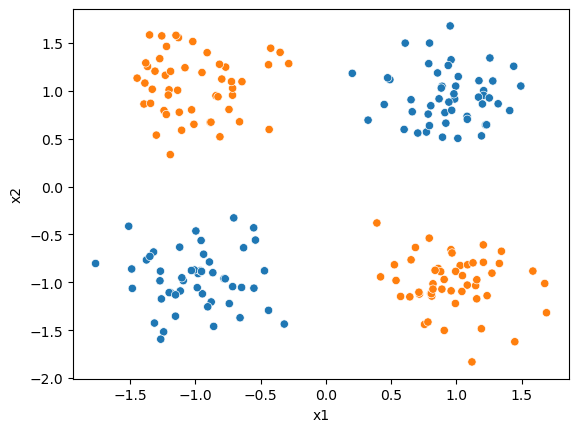

In [12]:
x, y = make_blobs(n_samples = [50, 50, 50, 50], n_features = 2, random_state = 0, centers = ((-1, -1), (-1, 1), (1, -1), (1, 1)), cluster_std = 0.3)
df = pd.DataFrame(data = x, columns = ["x1", "x2"])
df["y"] = y
df = df.replace(3, 0)
df = df.replace(2, 1)
sns.scatterplot(data = df, x = "x1", y = "x2", hue = "y", legend = False)

In [15]:
model = keras.Sequential([
    layers.Dense(3, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(2, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [16]:
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [17]:
np.random.seed(12)
history = model.fit(x = df[["x1", "x2"]],
                    y = df["y"],
                    epochs=5,
                    batch_size=8)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3400 - loss: 0.7045   
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4250 - loss: 0.6982 
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4500 - loss: 0.6935 
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4600 - loss: 0.6890 
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4950 - loss: 0.6845 


7813/7813 ━━━━━━━━━━━━━━━━━━━━ 4s 554us/step


<Axes: xlabel='fare', ylabel='age'>

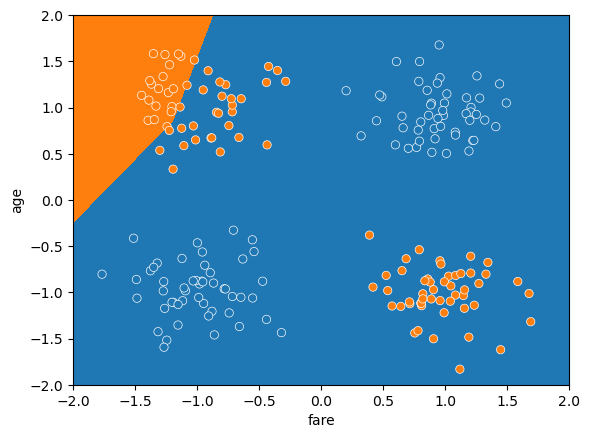

In [18]:
visualize_decision_boundaries(model, [-2, 2], [-2, 2])
sns.scatterplot(data = df, x = "x1", y = "x2", hue = "y", legend = False)


### a more complex neural network

In [19]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

np.random.seed(20)
history = model.fit(x = df[["x1", "x2"]],
                    y = df["y"],
                    epochs=20,
                    batch_size=8)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7400 - loss: 0.5599   
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8150 - loss: 0.4739 
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9200 - loss: 0.3936 
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9600 - loss: 0.3156 
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9900 - loss: 0.2452 
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.1867 
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.1398 
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.1013 
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0704 
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0470 
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0303 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

7813/7813 ━━━━━━━━━━━━━━━━━━━━ 4s 553us/step


<Axes: xlabel='fare', ylabel='age'>

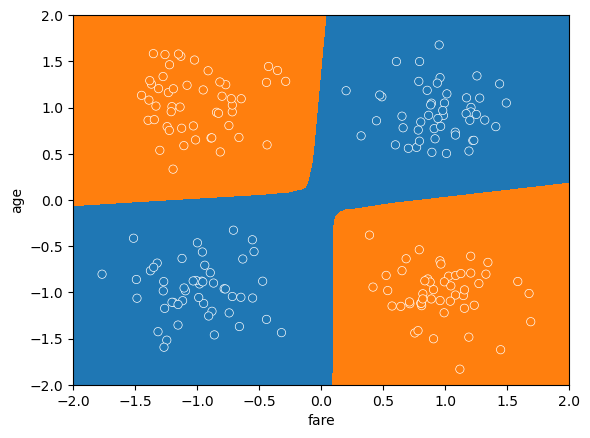

In [20]:
visualize_decision_boundaries(model, [-2, 2], [-2, 2])
sns.scatterplot(data = df, x = "x1", y = "x2", hue = "y", legend = False)
